# Phase 3 - NLP
Fake News Detection using NLP techniques: TF-IDF, Dense Neural Network, and Pretrained Embeddings

## Section 1 - Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from wordcloud import WordCloud
from sentence_transformers import SentenceTransformer

# download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("done")


c:\Users\mmmal\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


done


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mmmal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Section 2 - Load and Preprocess Data

We load the two CSV files (Fake.csv and True.csv), combine them, then:
- Merge title + text into one column
- Define a `clean_text` function to normalize the text
- Apply it to all rows

Same loading and cleaning as Phase 1 and Phase 2.


In [2]:
# load data — same as Phase 1 and Phase 2
fake = pd.read_csv('data/raw/Fake.csv')
true = pd.read_csv('data/raw/True.csv')

fake['label'] = 'FAKE'
true['label'] = 'REAL'

df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
df.head()


(44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL


In [3]:
# merge title and text into one column
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# convert label to 0/1
df['label_num'] = df['label'].map({'FAKE': 0, 'REAL': 1})


In [4]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    # lowercase
    text = text.lower()
    # remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # remove URLs
    text = re.sub(r'http\S+', ' ', text)
    # remove numbers
    text = re.sub(r'\d+', ' ', text)
    # remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    # tokenize and remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

df['content_clean'] = df['content'].apply(clean_text)

print("cleaning done")
df['content_clean'].head()


cleaning done


0    ben stein calls th circuit court committed cou...
1    trump drops steve bannon national security cou...
2    puerto rico expects u lift jones act shipping ...
3    oops trump accidentally confirmed leaked israe...
4    donald trump heads scotland reopen golf resort...
Name: content_clean, dtype: str

## Section 3 - Word Frequency Analysis

We count the 20 most common words in the entire cleaned dataset and plot a bar chart.


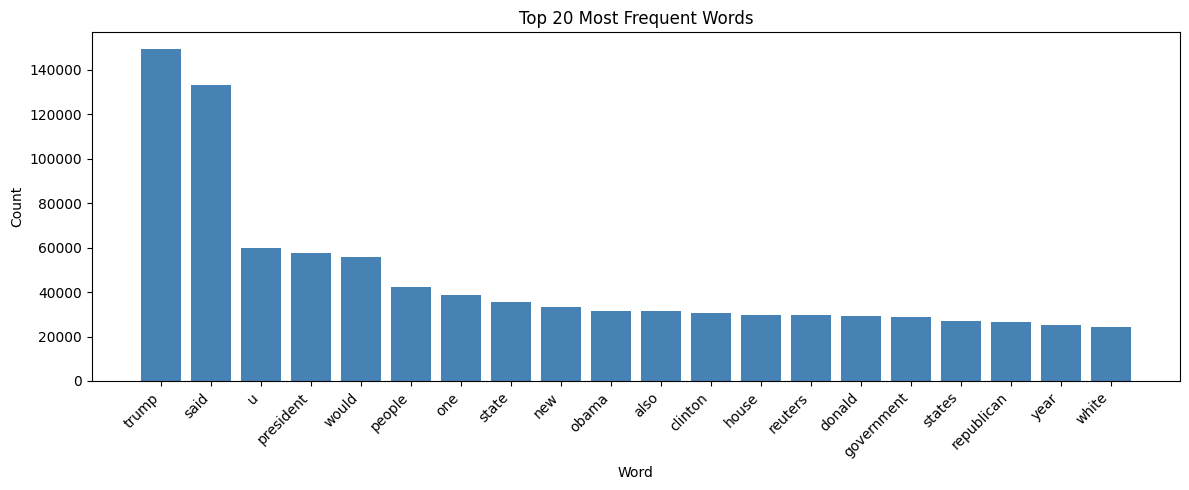

[('trump', 149466), ('said', 133033), ('u', 59659), ('president', 57643), ('would', 55666), ('people', 42496), ('one', 38738), ('state', 35618), ('new', 33086), ('obama', 31485), ('also', 31411), ('clinton', 30521), ('house', 29755), ('reuters', 29562), ('donald', 29141), ('government', 28676), ('states', 27140), ('republican', 26646), ('year', 25424), ('white', 24442)]


In [5]:
# combine all text and count words
all_words = ' '.join(df['content_clean']).split()
word_counts = Counter(all_words)
top20 = word_counts.most_common(20)

words, counts = zip(*top20)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(top20)


**Do these words make sense?**

Yes words like *said*, *trump*, *president*, *government*, *people* are very common in political news articles.
These are general political terms that appear across both REAL and FAKE news, so they are not very useful alone for classification.
However, there might be subtle frequency differences between FAKE and REAL that our models can pick up.


## Section 4 - TF-IDF Baseline

Same split (70/15/15) and TF-IDF (max 10,000 features) as Phase 1 and Phase 2.
We train a Logistic Regression on top of TF-IDF features as a quick baseline.


In [6]:
X = df['content_clean']
y = df['label_num']

# same split as Phase 1 and Phase 2 — 70/15/15, random_state=42
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_STATE, stratify=y_temp
)

print('train:', len(X_train))
print('val:  ', len(X_val))
print('test: ', len(X_test))


train: 31446
val:   6717
test:  6735


In [7]:
# TF-IDF — fit on train only (no leakage)
tfidf = TfidfVectorizer(max_features=10000)
X_train_vec = tfidf.fit_transform(X_train).toarray()
X_val_vec   = tfidf.transform(X_val).toarray()
X_test_vec  = tfidf.transform(X_test).toarray()

# Logistic Regression
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_vec, y_train)

# evaluate on test set
lr_preds = lr.predict(X_test_vec)
lr_f1 = round(f1_score(y_test, lr_preds), 4)
print('TF-IDF + LR  F1 on test:', lr_f1)
print()
print(classification_report(y_test, lr_preds, target_names=['FAKE', 'REAL']))


TF-IDF + LR  F1 on test: 0.9857

              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.99      3522
        REAL       0.98      0.99      0.99      3213

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



## Section 5 - Dense Neural Network

We build the same type of network used in Phase 2:
**Dense(128, relu) - Dense(64, relu) - Dense(1, sigmoid)**

The input is the same TF-IDF vector (10,000 features)


In [9]:
model_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_vec.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_nn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_nn.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9556 - loss: 0.1390 - val_accuracy: 0.9899 - val_loss: 0.0335
Epoch 2/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9959 - loss: 0.0148 - val_accuracy: 0.9903 - val_loss: 0.0332
Epoch 3/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9994 - loss: 0.0035 - val_accuracy: 0.9909 - val_loss: 0.0353
Epoch 4/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9999 - loss: 0.0019 - val_accuracy: 0.9908 - val_loss: 0.0371
Epoch 5/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 5.8906e-04 - val_accuracy: 0.9914 - val_loss: 0.0383


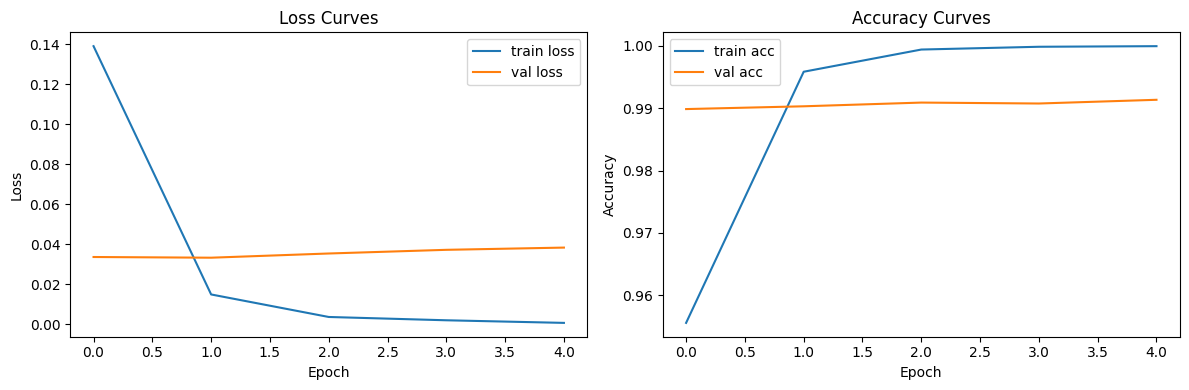

In [11]:
# plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
# evaluate on test set
nn_loss, nn_acc = model_nn.evaluate(X_test_vec, y_test, verbose=0)
nn_preds = (model_nn.predict(X_test_vec) > 0.5).astype(int).flatten()
nn_f1 = round(f1_score(y_test, nn_preds), 4)

print(f'Dense NN  Accuracy on test: {round(nn_acc, 4)}')
print(f'Dense NN  F1      on test: {nn_f1}')


211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Dense NN  Accuracy on test: 0.9898
Dense NN  F1      on test: 0.9893


In [13]:
# compare TF-IDF + LR  vs  Dense NN
comparison_df = pd.DataFrame({
    'Method':   ['TF-IDF + LR', 'Dense NN (Phase 3)'],
    'F1-Score': [lr_f1, nn_f1]
})
print(comparison_df.to_string(index=False))


            Method  F1-Score
       TF-IDF + LR    0.9857
Dense NN (Phase 3)    0.9893


## Section 6 - Pretrained Sentence Embeddings

We use `SentenceTransformer('all-MiniLM-L6-v2')` to get 384-dimensional sentence embeddings,
then train a Logistic Regression on top of them.

We use only **2,000 rows** because encoding ~45,000 rows would take too long.


In [14]:
# sample 2000 rows for speed
sample_df = df.sample(n=2000, random_state=RANDOM_STATE).reset_index(drop=True)

X_s = sample_df['content_clean']
y_s = sample_df['label_num']

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_s, y_s, test_size=0.20, random_state=RANDOM_STATE, stratify=y_s
)

print('sample train:', len(X_s_train), '  test:', len(X_s_test))


sample train: 1600   test: 400


In [15]:
# encode with SentenceTransformer
st_model = SentenceTransformer('all-MiniLM-L6-v2')

X_s_train_emb = st_model.encode(X_s_train.tolist(), show_progress_bar=True)
X_s_test_emb  = st_model.encode(X_s_test.tolist(),  show_progress_bar=True)

print('embedding shape:', X_s_train_emb.shape)


Batches: 100%|██████████| 13/13 [00:08<00:00,  1.49it/s]

embedding shape: (1600, 384)


In [16]:
# Logistic Regression on top of pretrained embeddings
lr_st = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_st.fit(X_s_train_emb, y_s_train)

st_preds = lr_st.predict(X_s_test_emb)
st_f1 = round(f1_score(y_s_test, st_preds), 4)

print('Pretrained Embeddings + LR  F1:', st_f1)
print()
print(classification_report(y_s_test, st_preds, target_names=['FAKE', 'REAL']))


Pretrained Embeddings + LR  F1: 0.8901

              precision    recall  f1-score   support

        FAKE       0.89      0.91      0.90       211
        REAL       0.90      0.88      0.89       189

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



## Section 7 - Word Clouds

We generate a word cloud for REAL news and another for FAKE news to visually compare the vocabularies.


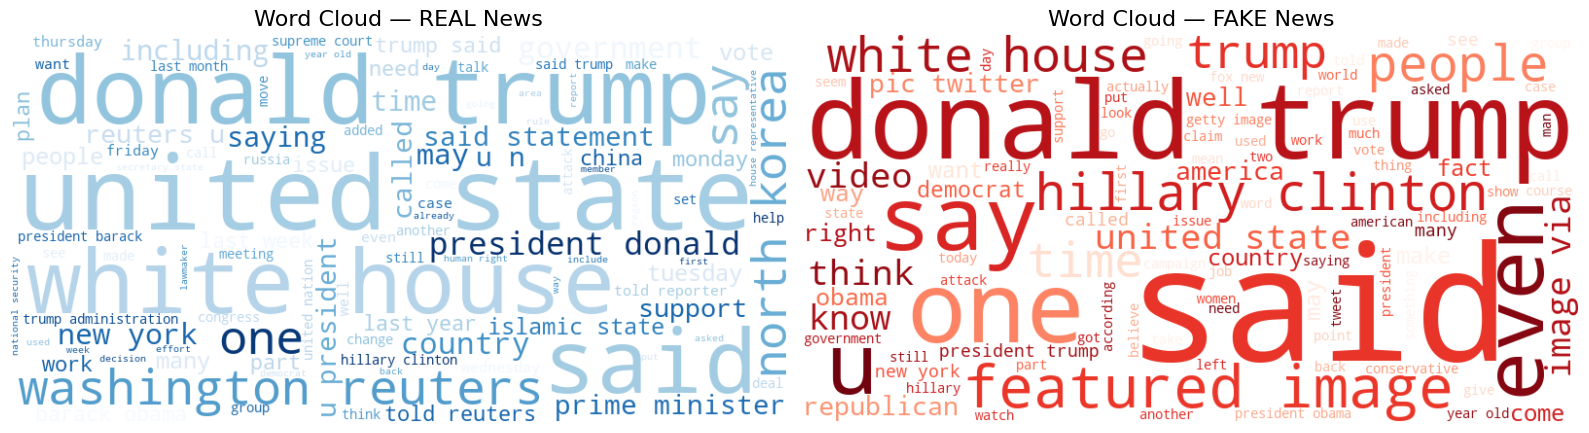

In [17]:
real_text = ' '.join(df[df['label'] == 'REAL']['content_clean'])
fake_text = ' '.join(df[df['label'] == 'FAKE']['content_clean'])

wc_real = WordCloud(width=800, height=400, background_color='white',
                    max_words=100, colormap='Blues').generate(real_text)

wc_fake = WordCloud(width=800, height=400, background_color='white',
                    max_words=100, colormap='Reds').generate(fake_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_real, interpolation='bilinear')
axes[0].set_title('Word Cloud — REAL News', fontsize=16)
axes[0].axis('off')

axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title('Word Cloud — FAKE News', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()


**What words stand out in each category?**

- **REAL News**: Words like *reuters*, *washington*, *said*, *government*, *official* tend to dominate -
  typical of professional wire-service reporting with formal language.
- **FAKE News**: Words like *trump*, *obama*, *clinton*, *people*, *video*, *share* appear more often -
  suggesting sensational or emotionally charged language typical of misinformation.

